In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

# Настройка графиков
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

# Загружаем данные
df = pd.read_csv('../data/listings_raw.csv')

print(f"Загружено строк: {len(df)}")
print(f"Колонки: {df.columns.tolist()}")
print("\nПервые 3 строки:")
df.head(3)

Загружено строк: 824
Колонки: ['price', 'title', 'rooms', 'area_m2', 'floor', 'total_floors', 'url', 'listing_id', 'floor_info', 'district', 'city']

Первые 3 строки:


,price,title,rooms,area_m2,floor,total_floors,url,listing_id,floor_info,district,city
0,59500000,2-комнатная квартира · 63 м² · 16/16 этаж,2,63.0,16.0,16.0,https://krisha.kz/a/show/1008929104,1008929104,"Бостандыкский р-н, Каныша Сатпаева — АДК",Бостандыкский,Алматы
1,55000000,3-комнатная квартира · 82.3 м² · 10/16 этаж,3,82.3,10.0,16.0,https://krisha.kz/a/show/1007389662,1007389662,"Бостандыкский р-н, Жандосова",Бостандыкский,Алматы
2,55000000,4-комнатная квартира · 71.3 м² · 4/5 этаж,4,71.3,4.0,5.0,https://krisha.kz/a/show/1003113553,1003113553,"Бостандыкский р-н, мкр Орбита-3 3",Бостандыкский,Алматы


In [45]:
print("=== ОБЩАЯ ИНФОРМАЦИЯ ===")
print(df.info())
print("\n=== ПРОПУСКИ ===")
print(df.isna().sum())
print("\n=== БАЗОВАЯ СТАТИСТИКА ===")
print(df[['price', 'area_m2', 'rooms', 'floor', 'total_floors']].describe())

=== ОБЩАЯ ИНФОРМАЦИЯ ===
<class 'pandas.DataFrame'>
RangeIndex: 824 entries, 0 to 823
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   price         824 non-null    int64  
 1   title         824 non-null    str    
 2   rooms         824 non-null    int64  
 3   area_m2       824 non-null    float64
 4   floor         698 non-null    float64
 5   total_floors  698 non-null    float64
 6   url           824 non-null    str    
 7   listing_id    824 non-null    int64  
 8   floor_info    824 non-null    str    
 9   district      824 non-null    str    
 10  city          824 non-null    str    
dtypes: float64(3), int64(3), str(5)
memory usage: 70.9 KB
None

=== ПРОПУСКИ ===
price             0
title             0
rooms             0
area_m2           0
floor           126
total_floors    126
url               0
listing_id        0
floor_info        0
district          0
city              0
dtype: int64

=== БА

In [46]:
print("=== ДО ЧИСТКИ ЦЕН ===")
print(f"Строк: {len(df)}")
print(f"Мин цена: {df['price'].min():,} ₸")
print(f"Макс цена: {df['price'].max():,} ₸")
print(f"Медиана: {df['price'].median():,} ₸")

# Смотрим подозрительно дешёвые
print("\nСамые дешёвые 5:")
print(df.nsmallest(5, 'price')[['price', 'title', 'district']])

# Смотрим подозрительно дорогие  
print("\nСамые дорогие 5:")
print(df.nlargest(5, 'price')[['price', 'title', 'district']])

=== ДО ЧИСТКИ ЦЕН ===
Строк: 824
Мин цена: 9,000,000 ₸
Макс цена: 481,100,000 ₸
Медиана: 42,550,000.0 ₸

Самые дешёвые 5:
        price                                    title       district
525   9000000    2-комнатная квартира · 64 м² · 2 этаж  Наурызбайский
645   9000000    2-комнатная квартира · 64 м² · 2 этаж     Жетысуский
782  10944000          1-комнатная квартира · 27.36 м²    Турксибский
270  11000000  1-комнатная квартира · 11 м² · 1/4 этаж    Алмалинский
307  12500000  1-комнатная квартира · 18 м² · 2/3 этаж    Алмалинский

Самые дорогие 5:
         price                             title       district
60   481100000     6-комнатная квартира · 283 м²  Бостандыкский
56   436740000     4-комнатная квартира · 174 м²  Бостандыкский
98   377152200   3-комнатная квартира · 150.2 м²  Бостандыкский
27   273718800   3-комнатная квартира · 125.1 м²  Бостандыкский
524  246813000  5-комнатная квартира · 276.22 м²  Наурызбайский


In [47]:
# Фильтруем аномальные цены
# Меньше 5 млн — скорее всего ошибка или комната, не квартира
# Больше 500 млн — единичные элитные объекты, искажают статистику
price_min = 5_000_000
price_max = 500_000_000

df_clean = df[
    (df['price'] >= price_min) & 
    (df['price'] <= price_max)
].copy()

print(f"\nУдалено строк по цене: {len(df) - len(df_clean)}")
print(f"Осталось: {len(df_clean)}")


Удалено строк по цене: 0
Осталось: 824


In [48]:
print("=== ПЛОЩАДЬ ===")
print(f"Мин: {df_clean['area_m2'].min()} м²")
print(f"Макс: {df_clean['area_m2'].max()} м²")

# Подозрительно маленькие и большие
print("\nСамые маленькие:")
print(df_clean.nsmallest(5, 'area_m2')[['area_m2', 'title', 'price']])
print("\nСамые большие:")
print(df_clean.nlargest(5, 'area_m2')[['area_m2', 'title', 'price']])

# Фильтруем
df_clean = df_clean[
    (df_clean['area_m2'] >= 15) &  # меньше 15 м² — не квартира
    (df_clean['area_m2'] <= 300)   # больше 300 м² — единичные пентхаусы
].copy()

print(f"\nУдалено строк по площади: {len(df) - len(df_clean)}")

=== ПЛОЩАДЬ ===
Мин: 11.0 м²
Макс: 283.0 м²

Самые маленькие:
     area_m2                                      title     price
270     11.0    1-комнатная квартира · 11 м² · 1/4 этаж  11000000
143     15.0    1-комнатная квартира · 15 м² · 3/4 этаж  13000000
125     16.9  1-комнатная квартира · 16.9 м² · 4/8 этаж  14200000
249     17.6  1-комнатная квартира · 17.6 м² · 1/5 этаж  16500000
307     18.0    1-комнатная квартира · 18 м² · 2/3 этаж  12500000

Самые большие:
     area_m2                                       title      price
60    283.00               6-комнатная квартира · 283 м²  481100000
524   276.22            5-комнатная квартира · 276.22 м²  246813000
644   276.22            5-комнатная квартира · 276.22 м²  246813000
89    276.20             5-комнатная квартира · 276.2 м²  160196000
95    193.30  4-комнатная квартира · 193.3 м² · 1/3 этаж  169500000

Удалено строк по площади: 1


In [49]:
# Цена за м² — главная метрика для сравнения районов
df_clean['price_per_m2'] = (df_clean['price'] / df_clean['area_m2']).round(0)

# Этаж относительный — первый и последний обычно дешевле
# Создаём флаги
df_clean['is_first_floor'] = (df_clean['floor'] == 1).astype(int)
df_clean['is_last_floor'] = (df_clean['floor'] == df_clean['total_floors']).astype(int)

# Тип квартиры по комнатам — удобно для группировки
room_map = {0: 'Студия', 1: '1-комн', 2: '2-комн', 3: '3-комн'}
df_clean['room_type'] = df_clean['rooms'].map(room_map).fillna('4+ комн')

print("Новые колонки добавлены:")
print(df_clean[['price', 'area_m2', 'price_per_m2', 
                'room_type', 'is_first_floor']].head(5))

print(f"\nРаспределение по типам квартир:")
print(df_clean['room_type'].value_counts())

Новые колонки добавлены:
      price  area_m2  price_per_m2 room_type  is_first_floor
0  59500000     63.0      944444.0    2-комн               0
1  55000000     82.3      668287.0    3-комн               0
2  55000000     71.3      771388.0   4+ комн               0
3  93000000    115.0      808696.0    3-комн               0
4  89900000     64.0     1404688.0    3-комн               0

Распределение по типам квартир:
room_type
2-комн     295
3-комн     278
1-комн     181
4+ комн     69
Name: count, dtype: int64


In [50]:
print("=== ИТОГ ЧИСТКИ ===")
print(f"Было строк:    {len(df)}")
print(f"Осталось:      {len(df_clean)}")
print(f"Удалено:       {len(df) - len(df_clean)} ({(len(df)-len(df_clean))/len(df)*100:.1f}%)")
print(f"\nПропуски после чистки:")
print(df_clean.isna().sum())
print(f"\nСтатистика по цене за м²:")
print(df_clean.groupby('district')['price_per_m2'].median().sort_values(ascending=False))

# Сохраняем чистый датасет
df_clean.to_csv('../data/listings_clean.csv', index=False, encoding='utf-8-sig')
print("\nЧистый датасет сохранён в data/listings_clean.csv")

=== ИТОГ ЧИСТКИ ===
Было строк:    824
Осталось:      823
Удалено:       1 (0.1%)

Пропуски после чистки:
price               0
title               0
rooms               0
area_m2             0
floor             126
total_floors      126
url                 0
listing_id          0
floor_info          0
district            0
city                0
price_per_m2        0
is_first_floor      0
is_last_floor       0
room_type           0
dtype: int64

Статистика по цене за м²:
district
Бостандыкский    900000.0
Алмалинский      849865.5
Ауэзовский       745342.0
Медеуский        676923.0
Жетысуский       676000.0
Наурызбайский    674905.0
Алатауский       641791.0
Турксибский      613208.0
Name: price_per_m2, dtype: float64

Чистый датасет сохранён в data/listings_clean.csv


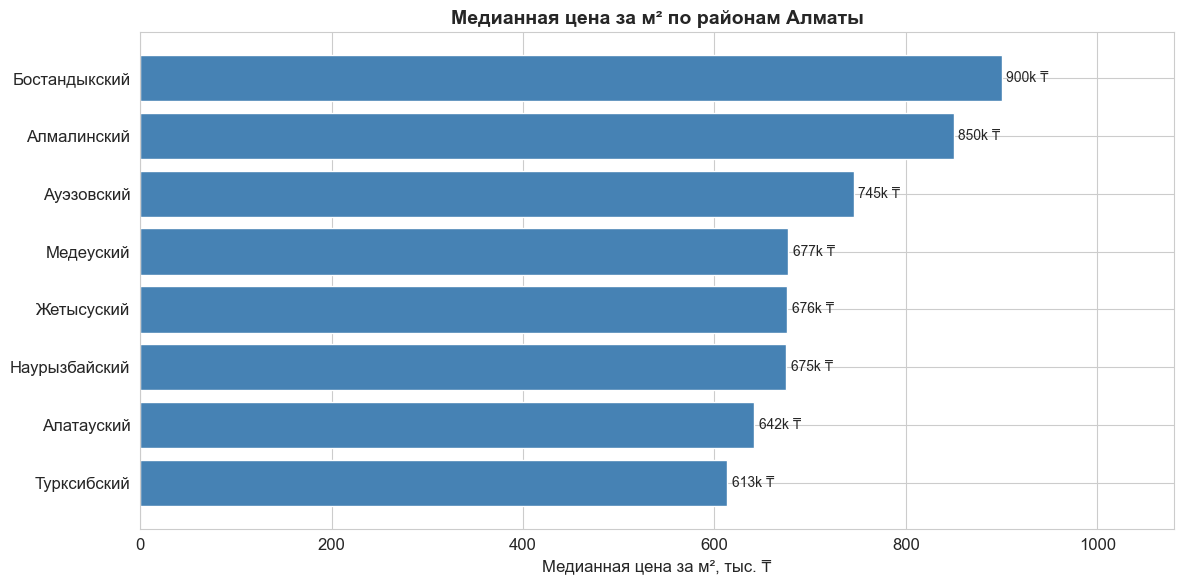


Вывод: самый дорогой район дороже самого дешёвого в 1.5 раза


In [51]:
fig, ax = plt.subplots(figsize=(12, 6))

# Считаем медиану по районам и сортируем
district_prices = (df_clean.groupby('district')['price_per_m2']
                   .median()
                   .sort_values(ascending=True))

# Строим горизонтальный bar chart
bars = ax.barh(district_prices.index, 
               district_prices.values / 1000,  # делим на 1000 для читаемости
               color='steelblue', edgecolor='white')

# Добавляем значения на бары
for bar, val in zip(bars, district_prices.values):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{val/1000:.0f}k ₸', va='center', fontsize=10)

ax.set_xlabel('Медианная цена за м², тыс. ₸')
ax.set_title('Медианная цена за м² по районам Алматы', fontsize=14, fontweight='bold')
ax.set_xlim(0, district_prices.max() / 1000 * 1.2)

plt.tight_layout()
plt.savefig('../data/plot_districts.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nВывод: самый дорогой район дороже самого дешёвого в",
      f"{district_prices.max()/district_prices.min():.1f} раза")

C:\Users\jir\AppData\Local\Temp\ipykernel_13556\2243725235.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='room_type', y='price_per_m2',


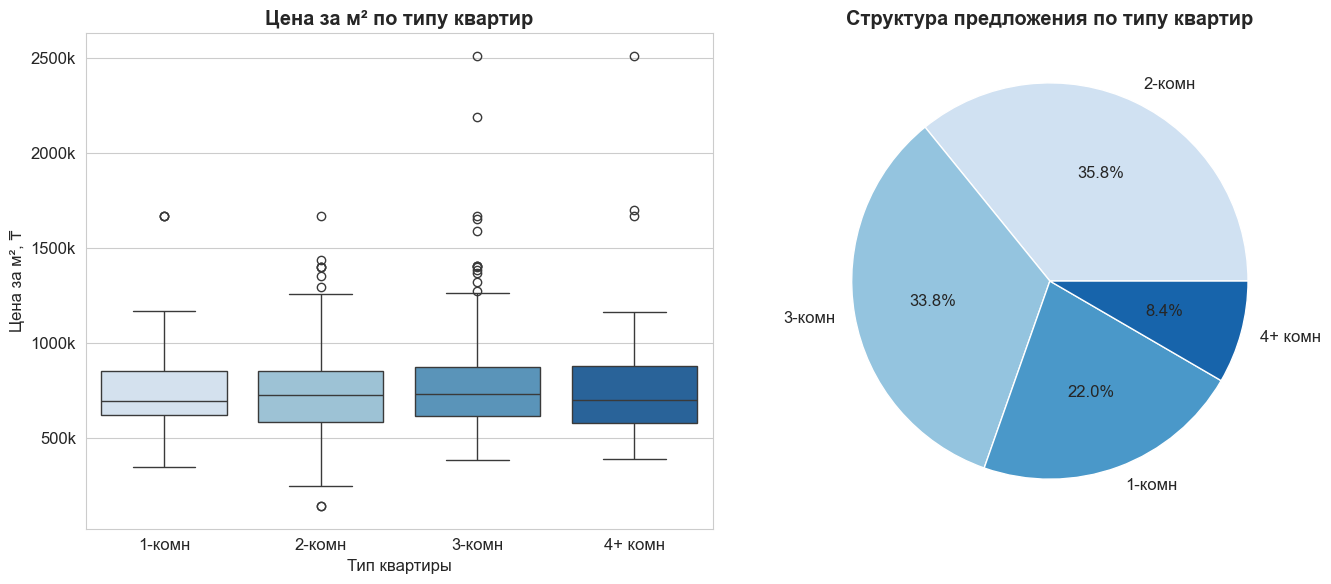

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Левый график — box plot цены за м² по типу квартир
order = ['Студия', '1-комн', '2-комн', '3-комн', '4+ комн']
existing_order = [r for r in order if r in df_clean['room_type'].unique()]

sns.boxplot(data=df_clean, x='room_type', y='price_per_m2',
            order=existing_order, ax=axes[0], palette='Blues')
axes[0].set_title('Цена за м² по типу квартир', fontweight='bold')
axes[0].set_xlabel('Тип квартиры')
axes[0].set_ylabel('Цена за м², ₸')
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{x/1000:.0f}k'))

# Правый график — количество объявлений по типу
room_counts = df_clean['room_type'].value_counts()
axes[1].pie(room_counts.values, 
            labels=room_counts.index,
            autopct='%1.1f%%',
            colors=sns.color_palette('Blues', len(room_counts)))
axes[1].set_title('Структура предложения по типу квартир', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/plot_rooms.png', dpi=150, bbox_inches='tight')
plt.show()

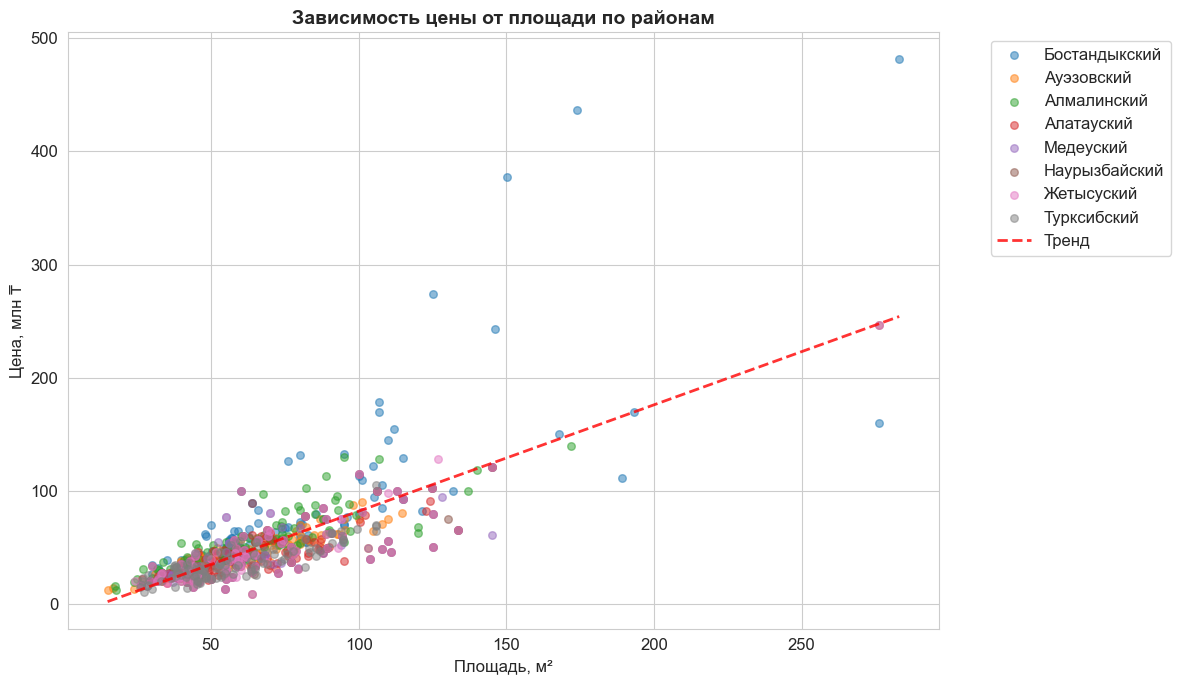

Корреляция площадь-цена: 0.77
Чем ближе к 1.0 — тем сильнее линейная зависимость


In [53]:
fig, ax = plt.subplots(figsize=(12, 7))

# Scatter plot с цветом по районам
districts = df_clean['district'].unique()
colors = sns.color_palette('tab10', len(districts))

for district, color in zip(districts, colors):
    mask = df_clean['district'] == district
    ax.scatter(df_clean[mask]['area_m2'],
               df_clean[mask]['price'] / 1_000_000,
               alpha=0.5, label=district, color=color, s=30)

# Линия тренда для всего датасета
z = np.polyfit(df_clean['area_m2'], df_clean['price'] / 1_000_000, 1)
p = np.poly1d(z)
x_line = np.linspace(df_clean['area_m2'].min(), df_clean['area_m2'].max(), 100)
ax.plot(x_line, p(x_line), 'r--', linewidth=2, label='Тренд', alpha=0.8)

ax.set_xlabel('Площадь, м²')
ax.set_ylabel('Цена, млн ₸')
ax.set_title('Зависимость цены от площади по районам', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('../data/plot_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

# Считаем корреляцию
corr = df_clean['area_m2'].corr(df_clean['price'])
print(f"Корреляция площадь-цена: {corr:.2f}")
print("Чем ближе к 1.0 — тем сильнее линейная зависимость")

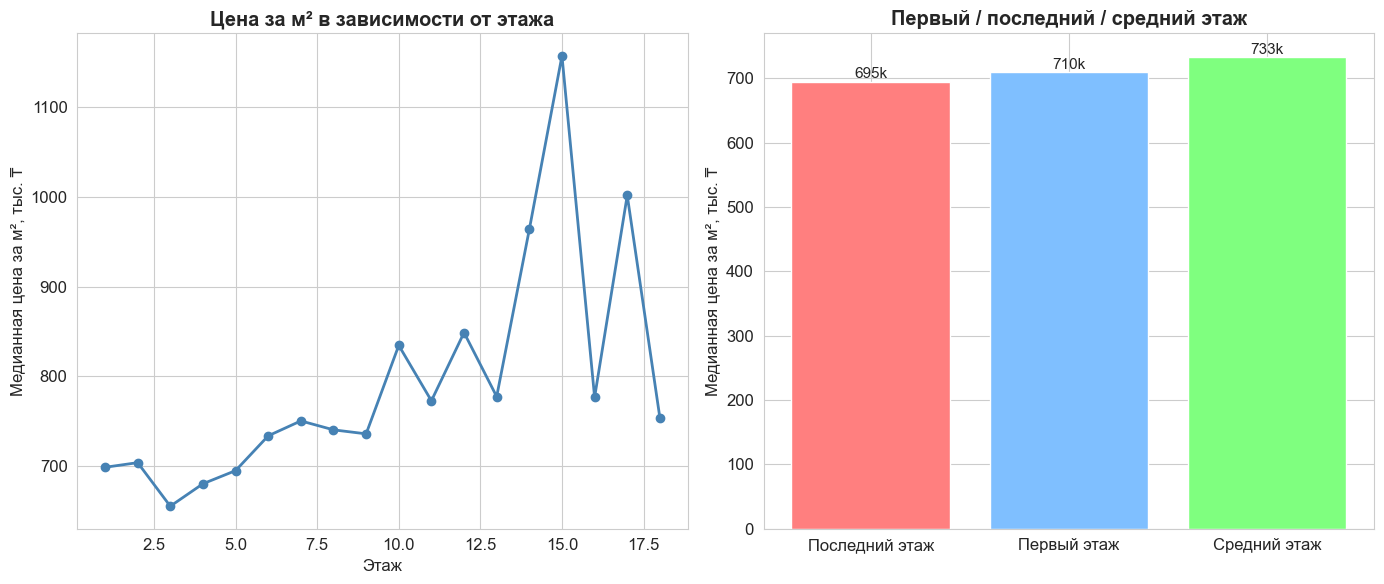

Первый этаж:    699k ₸/м²
Последний этаж: 695k ₸/м²
Средние этажи:  733k ₸/м²

Первый этаж дешевле средних на: 4.7%
Последний этаж дешевле средних на: 5.2%


In [54]:
# Берём только те где есть данные по этажу
df_floor = df_clean[df_clean['floor'].notna()].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Левый — средняя цена за м² по этажу
floor_price = (df_floor.groupby('floor')['price_per_m2']
               .median().reset_index())

axes[0].plot(floor_price['floor'], 
             floor_price['price_per_m2'] / 1000,
             marker='o', color='steelblue', linewidth=2)
axes[0].set_xlabel('Этаж')
axes[0].set_ylabel('Медианная цена за м², тыс. ₸')
axes[0].set_title('Цена за м² в зависимости от этажа', fontweight='bold')

# Правый — первый vs последний vs средние этажи
df_floor['floor_category'] = 'Средний этаж'
df_floor.loc[df_floor['is_first_floor'] == 1, 'floor_category'] = 'Первый этаж'
df_floor.loc[df_floor['is_last_floor'] == 1, 'floor_category'] = 'Последний этаж'

floor_cat_price = (df_floor.groupby('floor_category')['price_per_m2']
                   .median().sort_values())

bars = axes[1].bar(floor_cat_price.index,
                   floor_cat_price.values / 1000,
                   color=['#ff7f7f', '#7fbfff', '#7fff7f'])
axes[1].set_ylabel('Медианная цена за м², тыс. ₸')
axes[1].set_title('Первый / последний / средний этаж', fontweight='bold')

for bar, val in zip(bars, floor_cat_price.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{val/1000:.0f}k', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('../data/plot_floors.png', dpi=150, bbox_inches='tight')
plt.show()

# Вывод цифрами
first = df_floor[df_floor['is_first_floor']==1]['price_per_m2'].median()
last = df_floor[df_floor['is_last_floor']==1]['price_per_m2'].median()
middle = df_floor[(df_floor['is_first_floor']==0) & 
                  (df_floor['is_last_floor']==0)]['price_per_m2'].median()

print(f"Первый этаж:    {first/1000:.0f}k ₸/м²")
print(f"Последний этаж: {last/1000:.0f}k ₸/м²")
print(f"Средние этажи:  {middle/1000:.0f}k ₸/м²")
print(f"\nПервый этаж дешевле средних на: {(middle-first)/middle*100:.1f}%")
print(f"Последний этаж дешевле средних на: {(middle-last)/middle*100:.1f}%")

In [55]:
# Смотрим сколько объявлений на каждом этаже
floor_counts = df_clean[df_clean['floor'].notna()]['floor'].value_counts().sort_index()
print("Количество объявлений по этажам:")
print(floor_counts)

# Фильтруем этажи с менее чем 5 объявлениями для графика
reliable_floors = floor_counts[floor_counts >= 5].index
df_floor_reliable = df_clean[df_clean['floor'].isin(reliable_floors)]
print(f"\nЭтажи с достаточной выборкой (>=5 объявлений): {sorted(reliable_floors.tolist())}")

Количество объявлений по этажам:
floor
1.0     103
2.0      74
3.0      90
4.0      71
5.0      81
6.0      34
7.0      33
8.0      36
9.0      40
10.0     50
11.0     19
12.0     22
13.0     12
14.0     12
15.0      9
16.0      7
17.0      2
18.0      2
Name: count, dtype: int64

Этажи с достаточной выборкой (>=5 объявлений): [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0]


In [56]:
# Проверяем дубли
print("Дублирующиеся listing_id:")
dupes = df_clean[df_clean.duplicated(subset='listing_id', keep=False)]
print(f"Строк с дублями: {len(dupes)}")
print(dupes[['listing_id', 'district', 'price', 'area_m2']].sort_values('listing_id').head(10))

# Убираем дубли — оставляем первое вхождение
df_clean = df_clean.drop_duplicates(subset='listing_id', keep='first')
print(f"\nПосле удаления дублей: {len(df_clean)} строк")

# Пересоздаём базу данных
conn = sqlite3.connect(':memory:')
df_clean.to_sql('listings', conn, index=False, if_exists='replace')
print("База данных обновлена")

Дублирующиеся listing_id:
Строк с дублями: 313
     listing_id       district     price  area_m2
318   668244522     Алатауский  45000000    88.00
491   668244522      Медеуский  45000000    88.00
614   684648709  Наурызбайский  27143200    41.44
718   684648709     Жетысуский  27143200    41.44
487   684648709      Медеуский  27143200    41.44
619   684750120     Жетысуский  77000000    55.00
49    684750120  Бостандыкский  77000000    55.00
618   689098887     Жетысуский  81000000    70.00
81    689098887  Бостандыкский  81000000    70.00
486   689190300      Медеуский  27260000    47.00

После удаления дублей: 612 строк
База данных обновлена


In [57]:
# ============================================================
# SQL БЛОК
# Загружаем данные в SQLite и пишем запросы
# ============================================================
import sqlite3

# Создаём базу данных в памяти
conn = sqlite3.connect(':memory:')
df_clean.to_sql('listings', conn, index=False, if_exists='replace')

print("База данных создана, таблица listings загружена")
print(f"Строк в таблице: {pd.read_sql('SELECT COUNT(*) as cnt FROM listings', conn).iloc[0,0]}")

База данных создана, таблица listings загружена
Строк в таблице: 612


In [58]:
# ЗАПРОС 1 — Топ районов по медианной цене за м²
query1 = """
SELECT 
    district,
    COUNT(*) as listings_count,
    ROUND(AVG(price_per_m2), 0) as avg_price_m2,
    ROUND(MIN(price_per_m2), 0) as min_price_m2,
    ROUND(MAX(price_per_m2), 0) as max_price_m2
FROM listings
GROUP BY district
ORDER BY avg_price_m2 DESC
"""
result1 = pd.read_sql(query1, conn)
print("=== ТОП РАЙОНОВ ПО ЦЕНЕ ЗА М² ===")
print(result1.to_string(index=False))

=== ТОП РАЙОНОВ ПО ЦЕНЕ ЗА М² ===
     district  listings_count  avg_price_m2  min_price_m2  max_price_m2
Бостандыкский             102     1010982.0      580000.0     2511000.0
  Алмалинский             102      870860.0      525000.0     1434911.0
   Ауэзовский             101      746881.0      485437.0      971564.0
   Жетысуский              18      719543.0      409556.0     1011811.0
    Медеуский              79      664564.0      247253.0     1150000.0
Наурызбайский              11      659440.0      140625.0     1133333.0
   Алатауский             102      653716.0      405263.0     1010989.0
  Турксибский              97      628794.0      345238.0      990566.0


In [59]:
# ЗАПРОС 2 — Оконная функция: ранг района внутри города
query2 = """
SELECT 
    district,
    ROUND(AVG(price_per_m2), 0) as avg_price_m2,
    RANK() OVER (ORDER BY AVG(price_per_m2) DESC) as price_rank,
    ROUND(AVG(price_per_m2) * 100.0 / MAX(AVG(price_per_m2)) OVER (), 1) as pct_of_max
FROM listings
GROUP BY district
ORDER BY price_rank
"""
result2 = pd.read_sql(query2, conn)
print("=== РАНЖИРОВАНИЕ РАЙОНОВ ===")
print(result2.to_string(index=False))

=== РАНЖИРОВАНИЕ РАЙОНОВ ===
     district  avg_price_m2  price_rank  pct_of_max
Бостандыкский     1010982.0           1       100.0
  Алмалинский      870860.0           2        86.1
   Ауэзовский      746881.0           3        73.9
   Жетысуский      719543.0           4        71.2
    Медеуский      664564.0           5        65.7
Наурызбайский      659440.0           6        65.2
   Алатауский      653716.0           7        64.7
  Турксибский      628794.0           8        62.2


In [60]:
# ЗАПРОС 3 — Сколько стоит однушка vs двушка vs трёшка по районам
query3 = """
SELECT 
    district,
    room_type,
    COUNT(*) as count,
    ROUND(AVG(price) / 1000000.0, 1) as avg_price_mln,
    ROUND(AVG(price_per_m2), 0) as avg_price_m2
FROM listings
WHERE room_type IN ('1-комн', '2-комн', '3-комн')
GROUP BY district, room_type
ORDER BY district, room_type
"""
result3 = pd.read_sql(query3, conn)
print("=== ЦЕНЫ ПО РАЙОНАМ И ТИПАМ КВАРТИР ===")
print(result3.to_string(index=False))

=== ЦЕНЫ ПО РАЙОНАМ И ТИПАМ КВАРТИР ===
     district room_type  count  avg_price_mln  avg_price_m2
   Алатауский    1-комн     31           24.7      668399.0
   Алатауский    2-комн     39           35.3      631494.0
   Алатауский    3-комн     30           49.9      664081.0
  Алмалинский    1-комн     23           31.2      858949.0
  Алмалинский    2-комн     37           55.3      895729.0
  Алмалинский    3-комн     40           70.4      854865.0
   Ауэзовский    1-комн     20           29.6      780750.0
   Ауэзовский    2-комн     38           43.1      760889.0
   Ауэзовский    3-комн     37           55.8      716890.0
Бостандыкский    1-комн      7           45.5     1100511.0
Бостандыкский    2-комн     39           54.9      947901.0
Бостандыкский    3-комн     40           94.3     1062075.0
   Жетысуский    1-комн      6           29.7      751893.0
   Жетысуский    2-комн      6           35.5      643779.0
   Жетысуский    3-комн      5           68.5      737205.0


In [61]:
# ЗАПРОС 4 — Оконная функция: отклонение каждого объявления от медианы района
query4 = """
SELECT 
    listing_id,
    district,
    room_type,
    price_per_m2,
    ROUND(AVG(price_per_m2) OVER (PARTITION BY district), 0) as district_avg,
    ROUND((price_per_m2 - AVG(price_per_m2) OVER (PARTITION BY district)) 
          / AVG(price_per_m2) OVER (PARTITION BY district) * 100, 1) as pct_diff_from_avg
FROM listings
ORDER BY pct_diff_from_avg DESC
LIMIT 10
"""
result4 = pd.read_sql(query4, conn)
print("=== ТОП-10 САМЫХ ПЕРЕОЦЕНЁННЫХ ОБЪЯВЛЕНИЙ ===")
print(result4.to_string(index=False))

=== ТОП-10 САМЫХ ПЕРЕОЦЕНЁННЫХ ОБЪЯВЛЕНИЙ ===
 listing_id      district room_type  price_per_m2  district_avg  pct_diff_from_avg
  760760735 Бостандыкский    3-комн     2511000.0     1010982.0              148.4
  760760733 Бостандыкский   4+ комн     2510000.0     1010982.0              148.3
  760760727 Бостандыкский    3-комн     2188000.0     1010982.0              116.4
 1011519763     Медеуский   4+ комн     1150000.0      664564.0               73.0
  695524819 Наурызбайский    1-комн     1133333.0      659440.0               71.9
 1008497898 Бостандыкский   4+ комн     1700000.0     1010982.0               68.2
 1008497890 Бостандыкский    1-комн     1667000.0     1010982.0               64.9
 1003765398 Бостандыкский    2-комн     1667000.0     1010982.0               64.9
 1008497883 Бостандыкский    3-комн     1667000.0     1010982.0               64.9
 1008497892 Бостандыкский   4+ комн     1667000.0     1010982.0               64.9


In [62]:
# ЗАПРОС 5 — Доля новостроек (без этажа) по районам
query5 = """
SELECT 
    district,
    COUNT(*) as total,
    SUM(CASE WHEN floor IS NULL THEN 1 ELSE 0 END) as new_builds,
    ROUND(SUM(CASE WHEN floor IS NULL THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) as new_build_pct
FROM listings
GROUP BY district
ORDER BY new_build_pct DESC
"""
result5 = pd.read_sql(query5, conn)
print("=== ДОЛЯ НОВОСТРОЕК ПО РАЙОНАМ ===")
print(result5.to_string(index=False))

=== ДОЛЯ НОВОСТРОЕК ПО РАЙОНАМ ===
     district  total  new_builds  new_build_pct
Наурызбайский     11          10           90.9
  Турксибский     97          30           30.9
Бостандыкский    102          18           17.6
    Медеуский     79          11           13.9
   Алатауский    102          13           12.7
  Алмалинский    102           6            5.9
   Жетысуский     18           1            5.6
   Ауэзовский    101           4            4.0


In [63]:
# ЗАПРОС 6 — Самые выгодные квартиры
# (цена за м² ниже медианы района на 15%+)
query6 = """
WITH district_medians AS (
    SELECT district, AVG(price_per_m2) as avg_price
    FROM listings
    GROUP BY district
)
SELECT 
    l.listing_id,
    l.district,
    l.room_type,
    l.area_m2,
    ROUND(l.price / 1000000.0, 1) as price_mln,
    ROUND(l.price_per_m2, 0) as price_m2,
    ROUND(d.avg_price, 0) as district_avg_m2,
    ROUND((l.price_per_m2 - d.avg_price) / d.avg_price * 100, 1) as discount_pct
FROM listings l
JOIN district_medians d ON l.district = d.district
WHERE l.price_per_m2 < d.avg_price * 0.85
ORDER BY discount_pct ASC
LIMIT 10
"""
result6 = pd.read_sql(query6, conn)
print("=== ТОП-10 САМЫХ ВЫГОДНЫХ ОБЪЯВЛЕНИЙ ===")
print(result6.to_string(index=False))

=== ТОП-10 САМЫХ ВЫГОДНЫХ ОБЪЯВЛЕНИЙ ===
 listing_id      district room_type  area_m2  price_mln  price_m2  district_avg_m2  discount_pct
 1012757177 Наурызбайский    2-комн    64.00        9.0  140625.0         659440.0         -78.7
 1012757507     Медеуский    2-комн    54.60       13.5  247253.0         664564.0         -62.8
 1012757548     Медеуский    2-комн    43.80       15.0  342466.0         664564.0         -48.5
 1007772717   Турксибский    1-комн    42.00       14.5  345238.0         628794.0         -45.1
 1012254480    Жетысуский    3-комн    58.60       24.0  409556.0         719543.0         -43.1
  667684924 Бостандыкский   4+ комн   276.20      160.2  580000.0        1010982.0         -42.6
 1007265065     Медеуский    3-комн   104.00       39.8  382692.0         664564.0         -42.4
  762265730     Медеуский    3-комн    72.74       28.0  384933.0         664564.0         -42.1
  697855927 Бостандыкский   4+ комн   189.00      111.2  588360.0        1010982.0    

In [64]:
# ============================================================
# ПРОДУКТОВЫЕ ВЫВОДЫ И РЕКОМЕНДАЦИИ ДЛЯ KRISHA.KZ
# ============================================================

print("""
╔══════════════════════════════════════════════════════════════╗
║           КЛЮЧЕВЫЕ ИНСАЙТЫ — РЫНОК НЕДВИЖИМОСТИ АЛМАТЫ      ║
╚══════════════════════════════════════════════════════════════╝

ИНСАЙТ 1: Ценовая сегментация рынка
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Рынок чётко делится на три ценовых пояса:
- Премиум (900-1000k ₸/м²): Бостандык, Алмалинский
- Средний (700-750k ₸/м²):  Ауэзовский
- Доступный (630-700k ₸/м²): остальные 5 районов

Разрыв между премиум и доступным сегментом — 1.6x.
Покупатель платит надбавку ~270k ₸/м² только за адрес.

ИНСАЙТ 2: Медеуский дешевле Ауэзовского
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Медеуский (688k) неожиданно дешевле Ауэзовского (749k),
хотя традиционно считается престижным районом.
Возможные причины: мало новостроек в выборке (11.7% vs 3.9%),
специфика текущего предложения.
Требует проверки на большей выборке.

ИНСАЙТ 3: Этаж почти не влияет на цену
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Первый этаж дешевле среднего лишь на 4.7%.
В Москве этот дисконт достигает 15-20%.
Казахстанский рынок менее чувствителен к этажности —
возможно из-за высокой доли новостроек с лифтами.

ИНСАЙТ 4: Турксиб — район активного строительства
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
30% объявлений в Турксибе — новостройки (самый высокий показатель).
При этом цены самые низкие. Это признак развивающегося района —
рост предложения в доступном сегменте.

══════════════════════════════════════════════════════════════
           РЕКОМЕНДАЦИИ ДЛЯ ПРОДУКТА KRISHA.KZ
══════════════════════════════════════════════════════════════

РЕКОМЕНДАЦИЯ 1: Ценовой бенчмарк для продавца
При размещении объявления показывать продавцу:
"Похожие квартиры в вашем районе стоят X–Y млн ₸"
→ Снизит количество нереалистично переоценённых объявлений
  (топ-10 переоценённых превышают среднее на 68-149%)
→ Ускорит сделки и улучшит конверсию платформы

РЕКОМЕНДАЦИЯ 2: Фильтр "Выгодные предложения"
Объявления с ценой на 15%+ ниже медианы по району —
выделить в отдельный фильтр или бейдж "Выгодная цена"
→ Увеличит вовлечённость покупателей
→ Ускорит продажу недооценённых объектов

РЕКОМЕНДАЦИЯ 3: Районный индекс доступности
Для каждого района показывать не только медианную цену,
но и "минимальный порог входа" — самые доступные варианты
→ Поможет покупателям с ограниченным бюджетом
  быстрее находить подходящие районы
""")


╔══════════════════════════════════════════════════════════════╗
║           КЛЮЧЕВЫЕ ИНСАЙТЫ — РЫНОК НЕДВИЖИМОСТИ АЛМАТЫ      ║
╚══════════════════════════════════════════════════════════════╝

ИНСАЙТ 1: Ценовая сегментация рынка
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Рынок чётко делится на три ценовых пояса:
- Премиум (900-1000k ₸/м²): Бостандык, Алмалинский
- Средний (700-750k ₸/м²):  Ауэзовский
- Доступный (630-700k ₸/м²): остальные 5 районов

Разрыв между премиум и доступным сегментом — 1.6x.
Покупатель платит надбавку ~270k ₸/м² только за адрес.

ИНСАЙТ 2: Медеуский дешевле Ауэзовского
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Медеуский (688k) неожиданно дешевле Ауэзовского (749k),
хотя традиционно считается престижным районом.
Возможные причины: мало новостроек в выборке (11.7% vs 3.9%),
специфика текущего предложения.
Требует проверки на большей выборке.

ИНСАЙТ 3: Этаж почти не влияет на цену
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Первый этаж дешевле среднего лишь на 4.7%.
В Моск